## K-Means Model

In [3]:
%pip install pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.8 MB 13.5 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.8 MB 15.8 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 16.6 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 16.1 MB/s  0:00:00
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.7 MB 15.7 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.7 MB 13.5 MB/s eta 0:00:01
   --------------------------- ------------ 8.7/12.7 MB 14.5 MB/s eta 0:00:01
   ----------------------------------- ---- 11.3/12.7 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 12.7/12.7 MB 12.7 MB/s  0:00:01
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.5 MB 12.2 MB/s eta 0:00:01
   ------------------

In [4]:
# Step 1 : Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Step 2 : Load the dataset
df = pd.read_csv(r'C:\Users\HARSHITHA\Desktop\FSDS\K-Means Clustering\Mall_Customers.csv')

In [6]:
# Step 3 : Data Preprocessing
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# check the missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

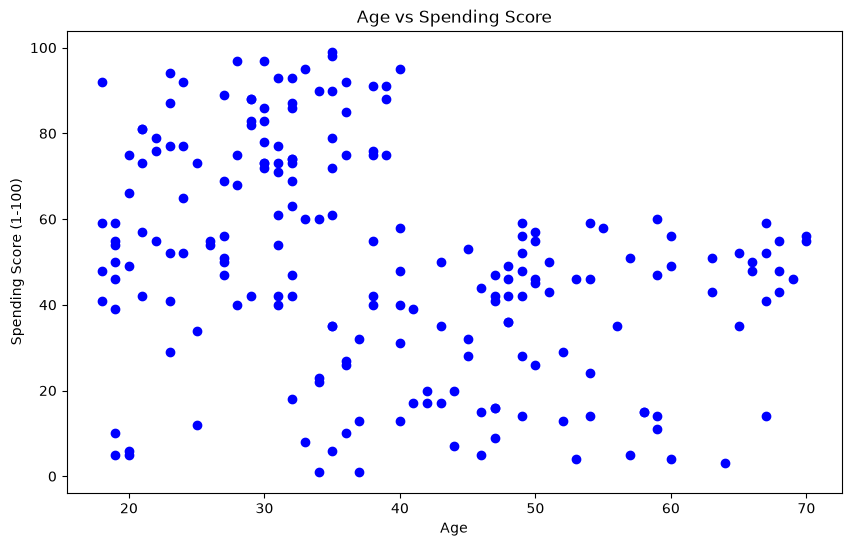

In [8]:
# Make the scatter plot 

plt.figure(figsize=(10, 6))
plt.scatter(df['Age'],df['Spending Score (1-100)'], color='blue')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.title('Age vs Spending Score')
plt.show()

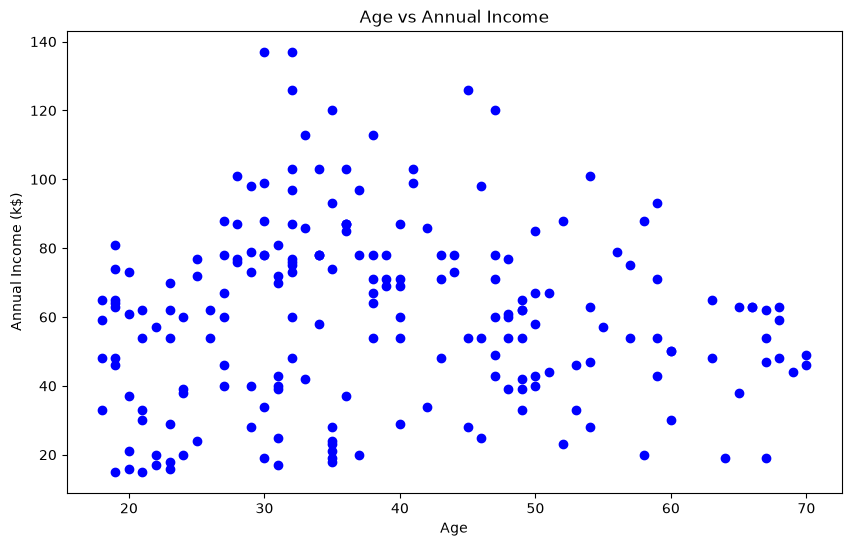

In [9]:
# Make Age and Income columns Scatter plot

plt.figure(figsize=(10, 6))
plt.scatter(df['Age'],df['Annual Income (k$)'], color='blue')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Age vs Annual Income')
plt.show()

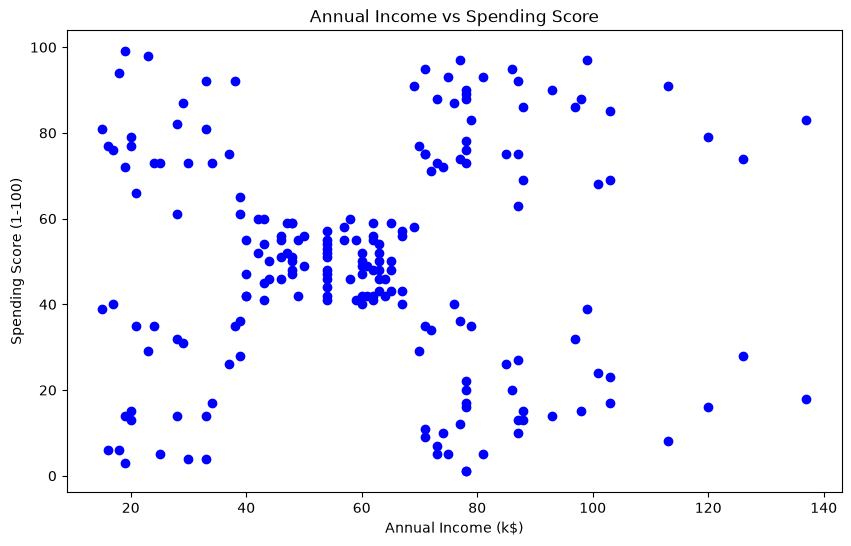

In [10]:
# make the scatter plot for Annual Income and Spending Score
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], color='blue')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score')
plt.show()

In [11]:
# Drop the 'CustomerID', Gender columns as they are not required for clustering
df.drop(['CustomerID', 'Gender'], axis=1, inplace=True)

In [12]:
df.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='str')

In [16]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.4 MB 15.6 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.4 MB 14.8 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.4 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 11.9 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.6/37.4 MB 8.6 MB/s eta 0:00:05
   --- ------------------------------------ 3.4/37.4 MB 9.3 MB/s eta 0:00:04
   ----- ---------------------------------- 5.5/37.4 MB 9.1 MB/s eta 0:00:04
   ------- -------------------------------- 7.1/37.4 MB 9.1 MB/s eta 0:00:04
   --------- ------------------------------ 8.7/37.4 MB 8.5 MB/s eta 0:00:04
   ---------- ----------------------------- 10.2/37.4 MB 8.3 MB/s eta 0:00:04
   ------------ --------------------------- 11.5/37.4 MB 8.1 MB/s eta 0:00:04
   ------------

In [17]:
# Step 4 : Feature Scaling
from sklearn.preprocessing import StandardScaler

#create an instance of StandardScaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [18]:
# Train the KMeans model
from sklearn.cluster import KMeans

# create an instance of KMeans with 5 clusters
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit the model to the scaled data
kmeans.fit(scaled_data)

# Get the cluster labels
labels = kmeans.labels_

# print the cluster labels
print(labels)

[2 2 2 2 2 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 2 2 0 2 2 0 0 0 0 0 2 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0
 0 2 0 0 2 0 0 2 0 0 2 0 0 2 2 0 0 2 0 0 2 2 0 2 0 2 2 0 0 2 0 2 0 0 0 0 0
 2 3 2 2 2 0 0 0 0 2 3 1 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [19]:
# check the model evaluation silhouette score
from sklearn.metrics import silhouette_score

# calculate the silhouette score
silhouette_avg = silhouette_score(scaled_data, labels)

# print the silhouette score
print("The silhouette score is :", silhouette_avg)

The silhouette score is : 0.4039582785148566


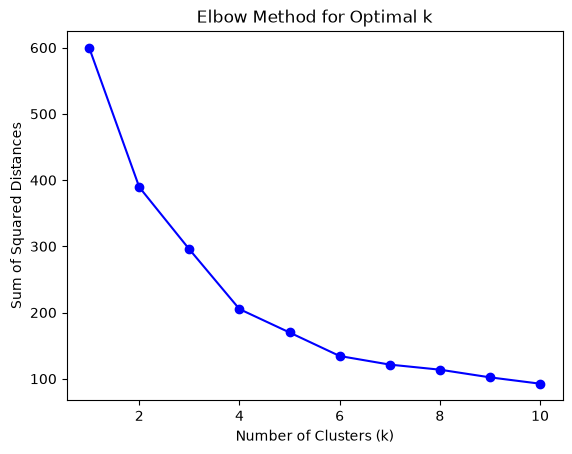

In [20]:
# make the elbow plot to find the optimal number of clusters




# calculate the sum of squared distances for different numbers of clusters
ssd = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    ssd.append(kmeans.inertia_)

# plot the elbow curve
plt.plot(K_range, ssd, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()

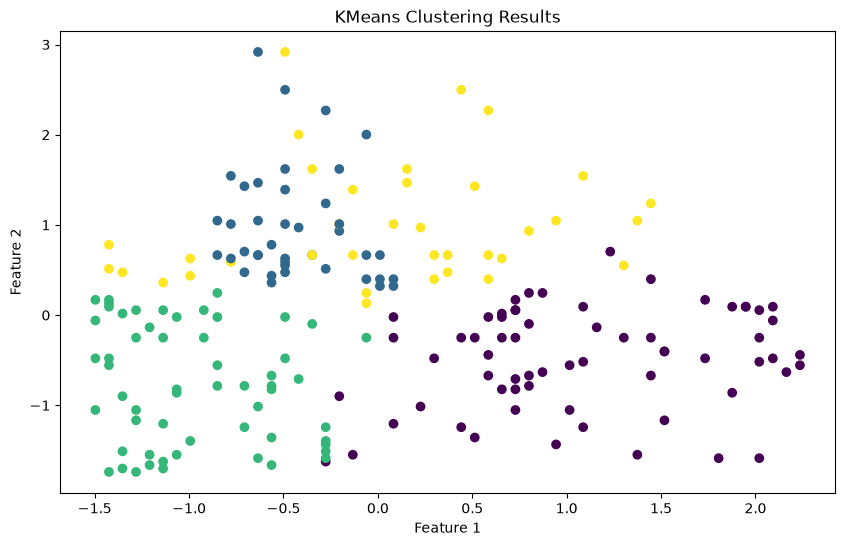

In [21]:
# Step 5 : Visualize the clusters

# using label visaulization

plt.figure(figsize=(10, 6))

plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering Results')
plt.show()

## Hierarchical Clustering


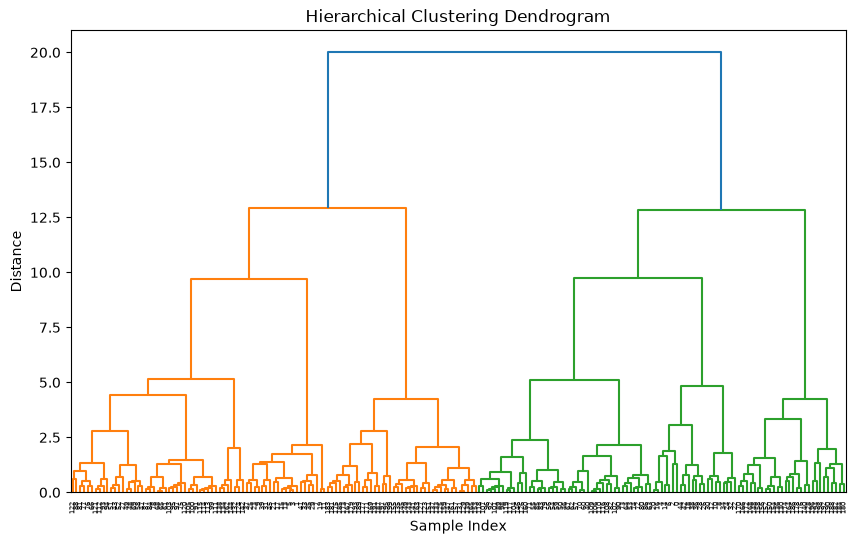

In [22]:
from sklearn.cluster import AgglomerativeClustering
# import dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Create a linkage matrix
linked = linkage(scaled_data, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [23]:
# create an instance of AgglomerativeClustering with 4 clusters
agg_clustering = AgglomerativeClustering(n_clusters=4)

# Fit the model to the scaled data
agg_clustering.fit(scaled_data)

# Get the cluster labels
agg_labels = agg_clustering.labels_



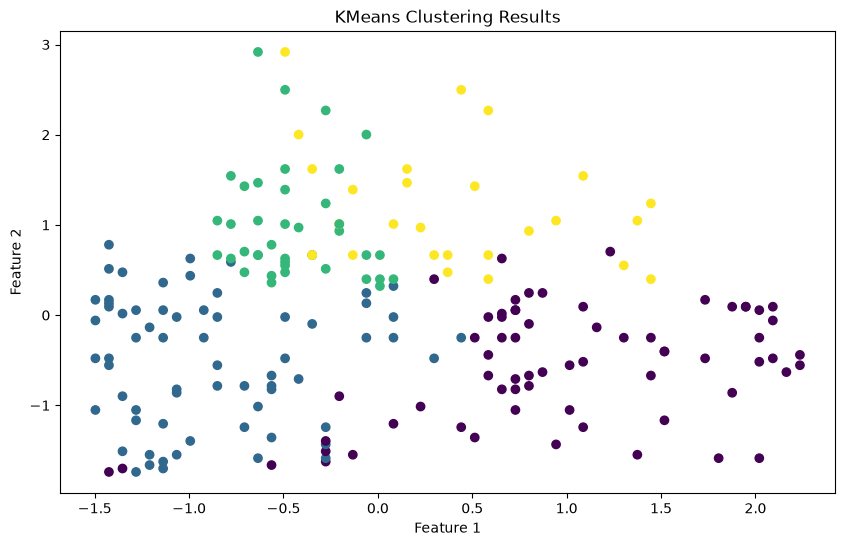

In [24]:
# make the cluster plot 
plt.figure(figsize=(10, 6))

plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=agg_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering Results')
plt.show()